In [94]:
import pandas as pd
import numpy as np

# Data Splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# Machine Learning Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Model Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv('/content/heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [96]:
print(df.isna().sum()) #no null values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [97]:
df.describe()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [98]:
df.shape


(1025, 14)

In [99]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [100]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [101]:
df.info() #observed that all of the rows are numeric thus no need of encoding categorical values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


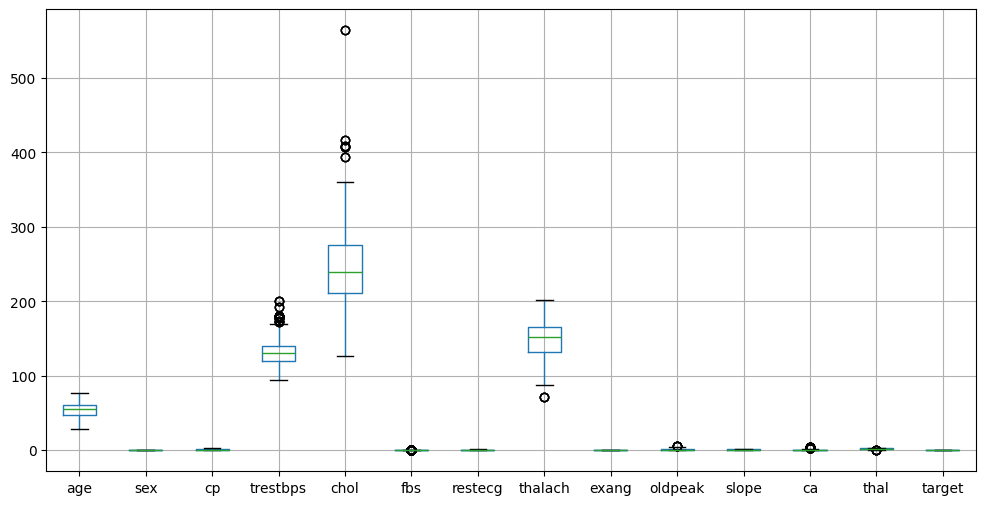

In [102]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))

plt.show()

In [103]:
df['chol'].describe() #cholestrol has a very high skew value, with 564 greatest value but the val is kept because it is not incorrect data the outlier exists in irl

,chol
count,1025.00000
mean,246.00000
std,51.59251
min,126.00000
25%,211.00000
50%,240.00000
75%,275.00000
max,564.00000


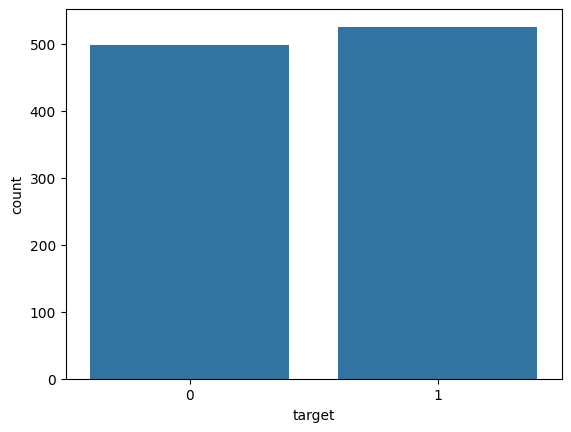

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)

plt.show() #target is ok not biased so its fine

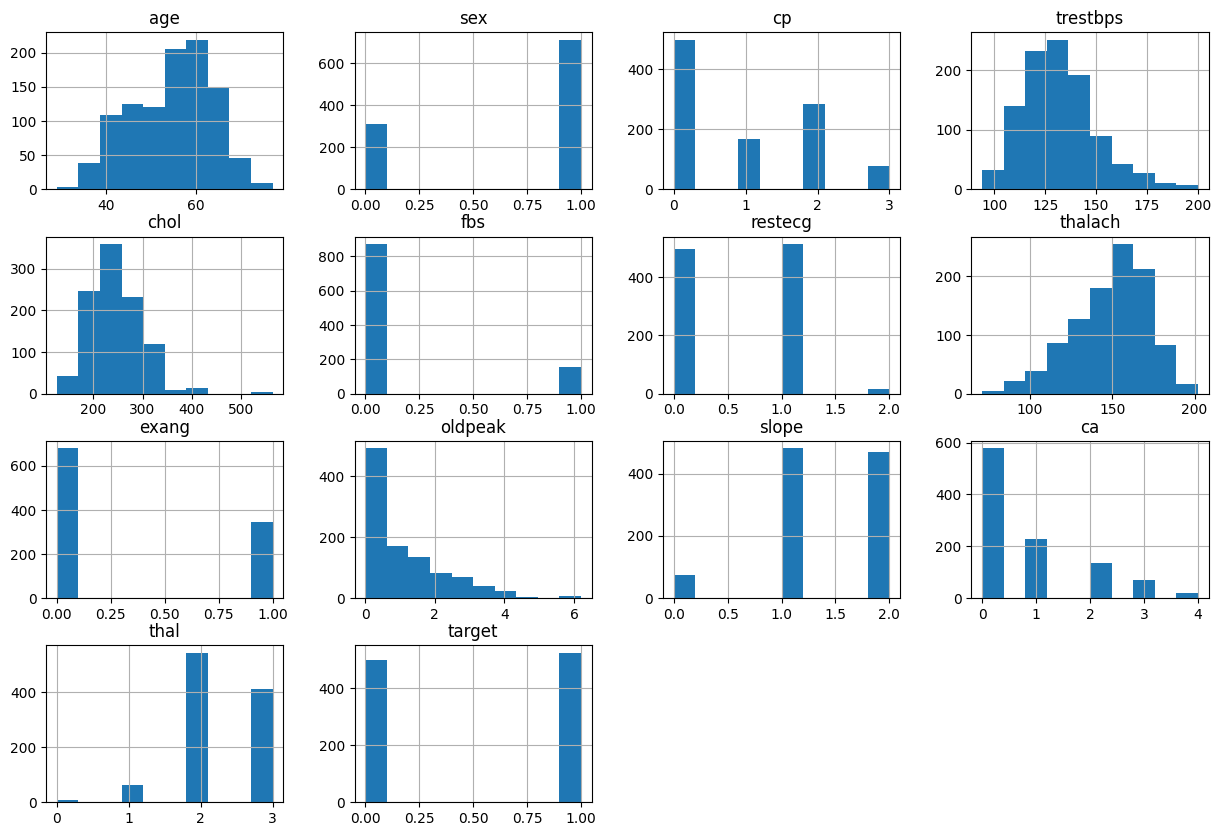

In [105]:
df.hist(figsize=(15,10))

plt.show() #there is a small skew in thalach it is acceptable

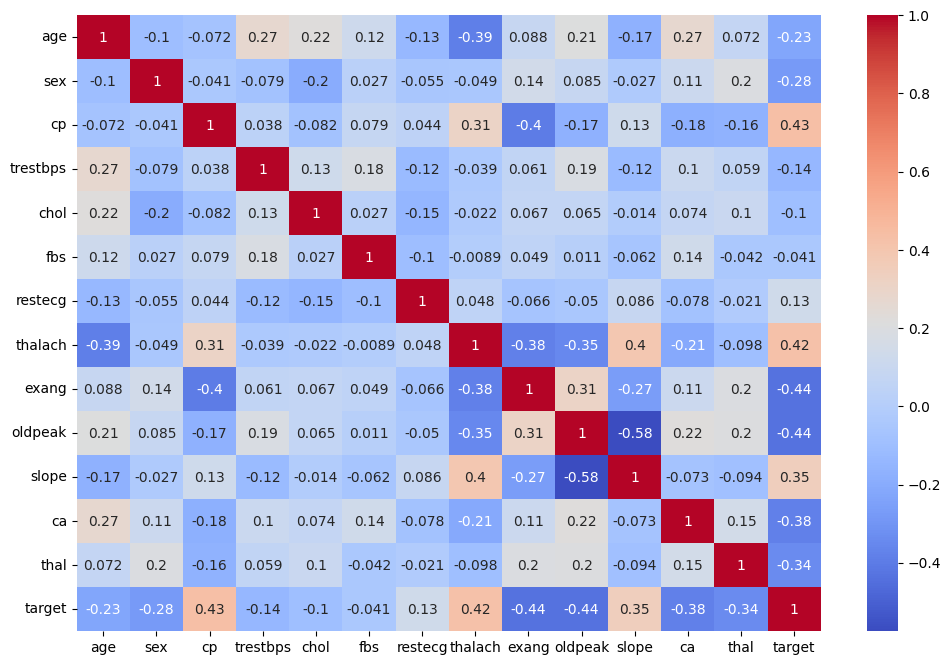

In [106]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

In [107]:
df.duplicated().sum()

np.int64(723)


Column: sex
sex
1    713
0    312
Name: count, dtype: int64


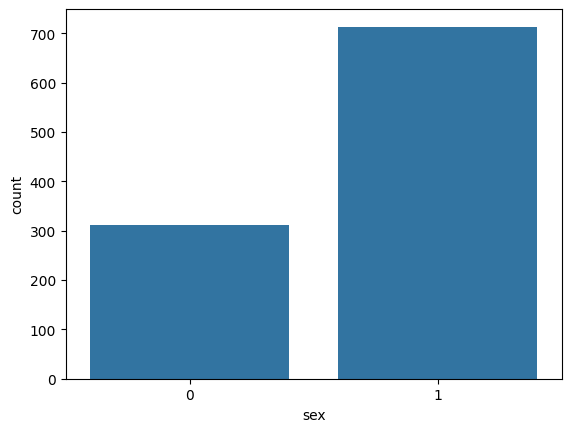


Column: cp
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64


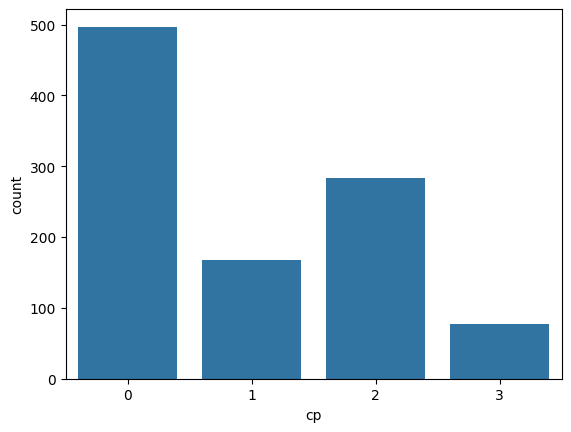


Column: fbs
fbs
0    872
1    153
Name: count, dtype: int64


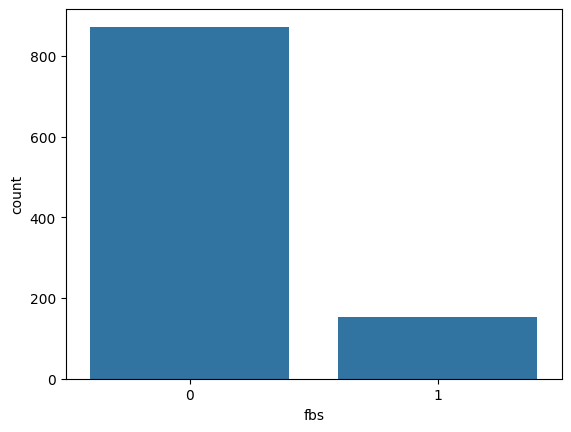


Column: restecg
restecg
1    513
0    497
2     15
Name: count, dtype: int64


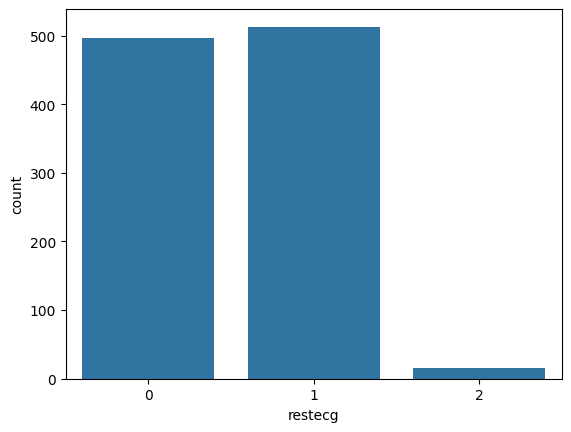


Column: exang
exang
0    680
1    345
Name: count, dtype: int64


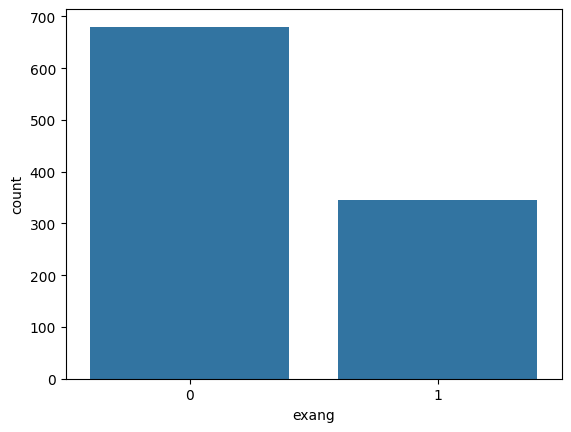


Column: slope
slope
1    482
2    469
0     74
Name: count, dtype: int64


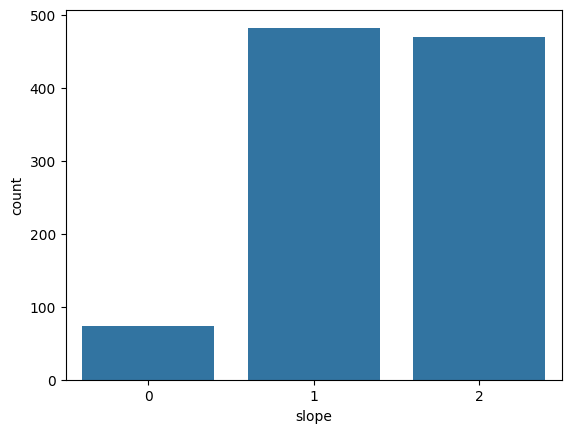


Column: ca
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64


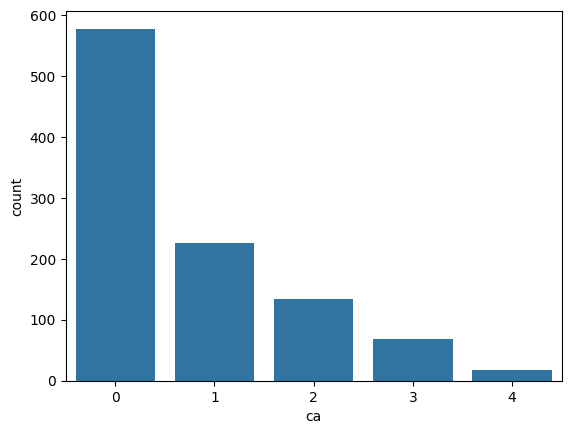


Column: thal
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64


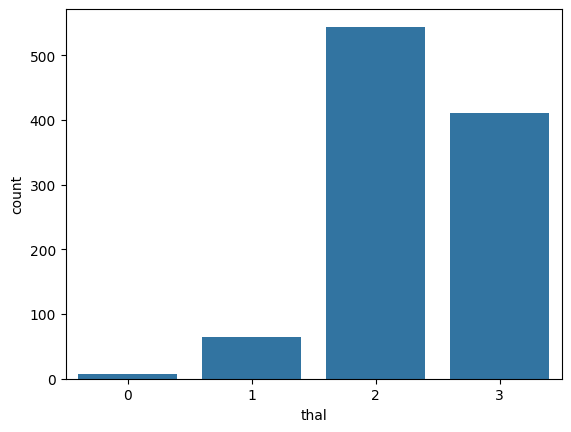


Column: target
target
1    526
0    499
Name: count, dtype: int64


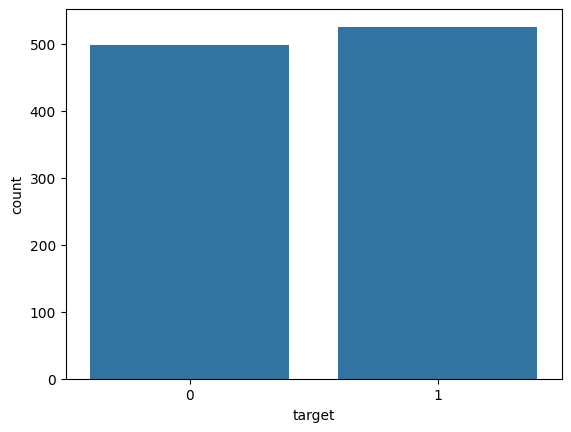

In [108]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg',
            'exang', 'slope', 'ca', 'thal', 'target']

for col in cat_cols:

    print("\nColumn:", col)
    print(df[col].value_counts())

    sns.countplot(x=col, data=df)
    plt.show()    #thal has less than 1% in cat 0 so it has to be inspected and found out that the duplication is affecting it


In [109]:
df[df['thal'] == 0]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
319,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
329,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
686,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
734,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
893,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0


In [110]:
duplicates = df[df.duplicated()]

print(duplicates) #there are a lot of duplicated rows of around 700 so dropped it

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [111]:
df = df.drop_duplicates()

In [112]:
df.shape

(302, 14)


Column: sex
sex
1    206
0     96
Name: count, dtype: int64


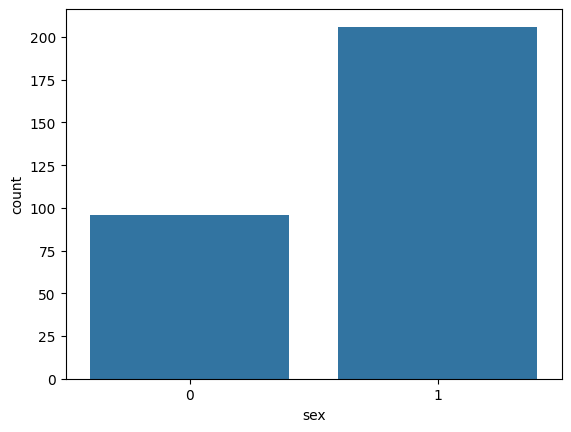


Column: cp
cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64


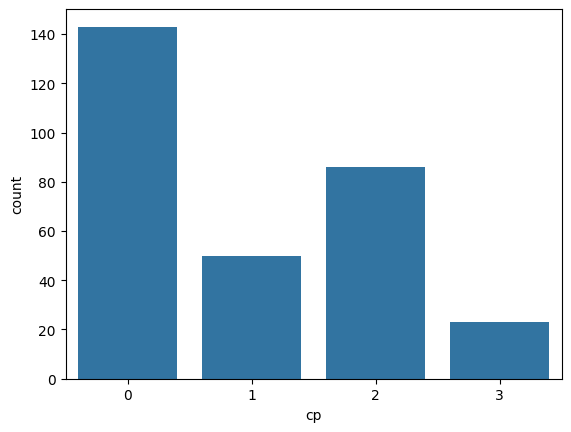


Column: fbs
fbs
0    257
1     45
Name: count, dtype: int64


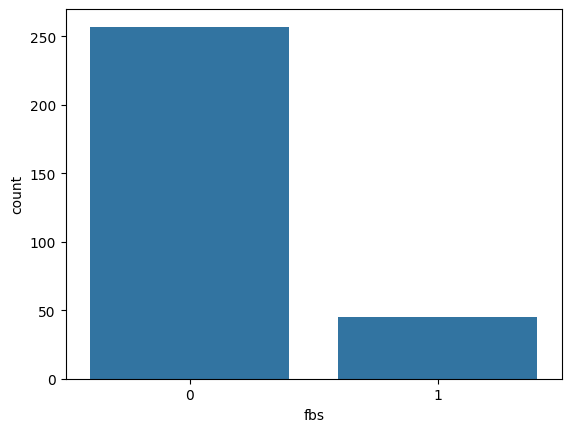


Column: restecg
restecg
1    151
0    147
2      4
Name: count, dtype: int64


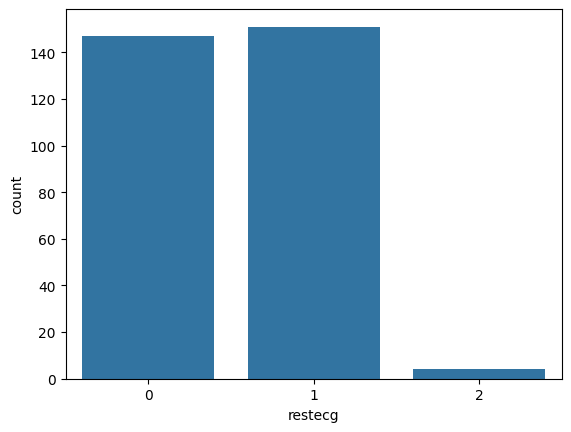


Column: exang
exang
0    203
1     99
Name: count, dtype: int64


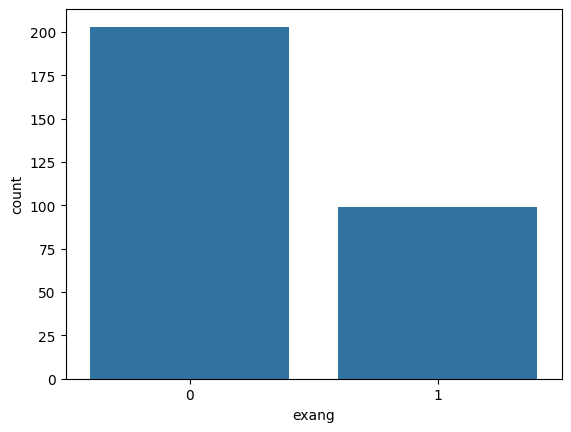


Column: slope
slope
2    141
1    140
0     21
Name: count, dtype: int64


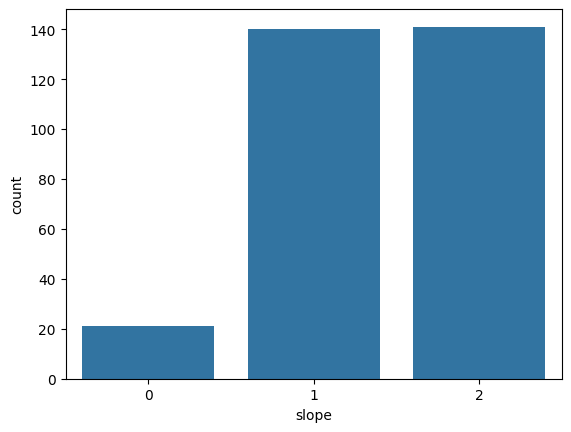


Column: ca
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64


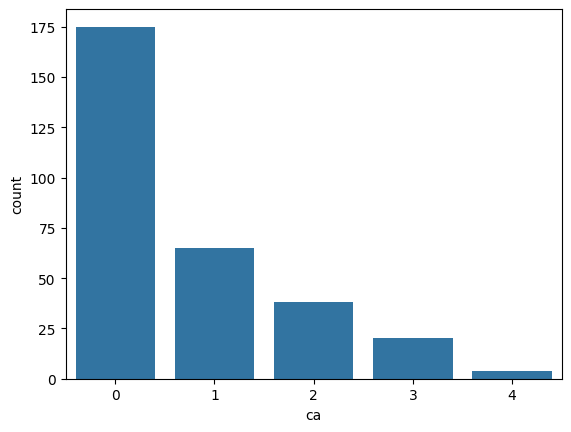


Column: thal
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


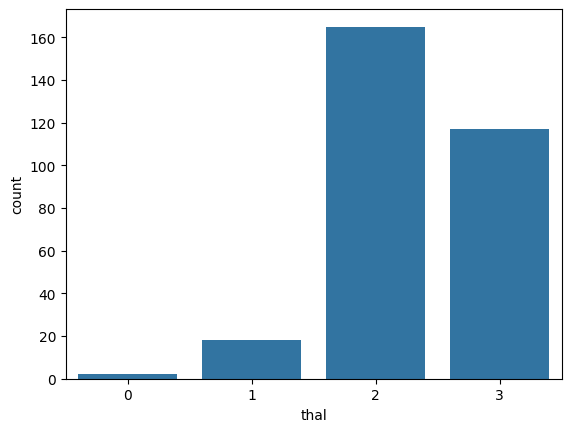


Column: target
target
1    164
0    138
Name: count, dtype: int64


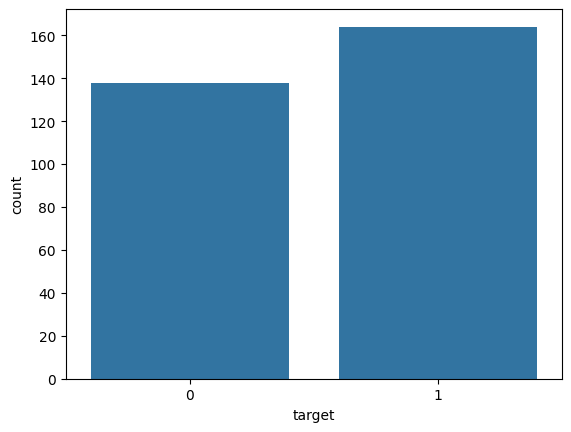

In [113]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg',
            'exang', 'slope', 'ca', 'thal', 'target']

for col in cat_cols:

    print("\nColumn:", col)
    print(df[col].value_counts())

    sns.countplot(x=col, data=df)
    plt.show()

In [114]:
df = df[df['thal'] != 0] #removed thal=0 as the value is around 0.66% so most likely a placeholder or a fault

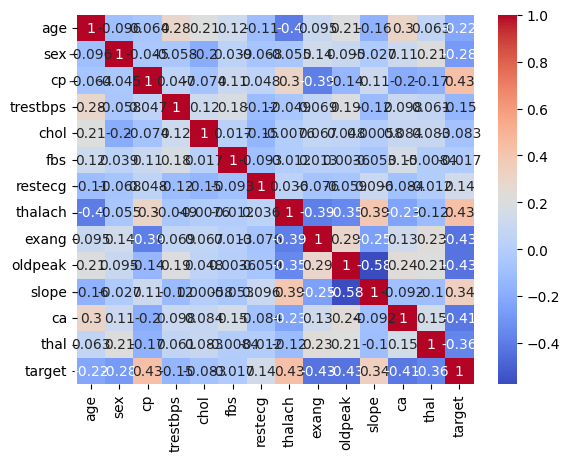

In [115]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

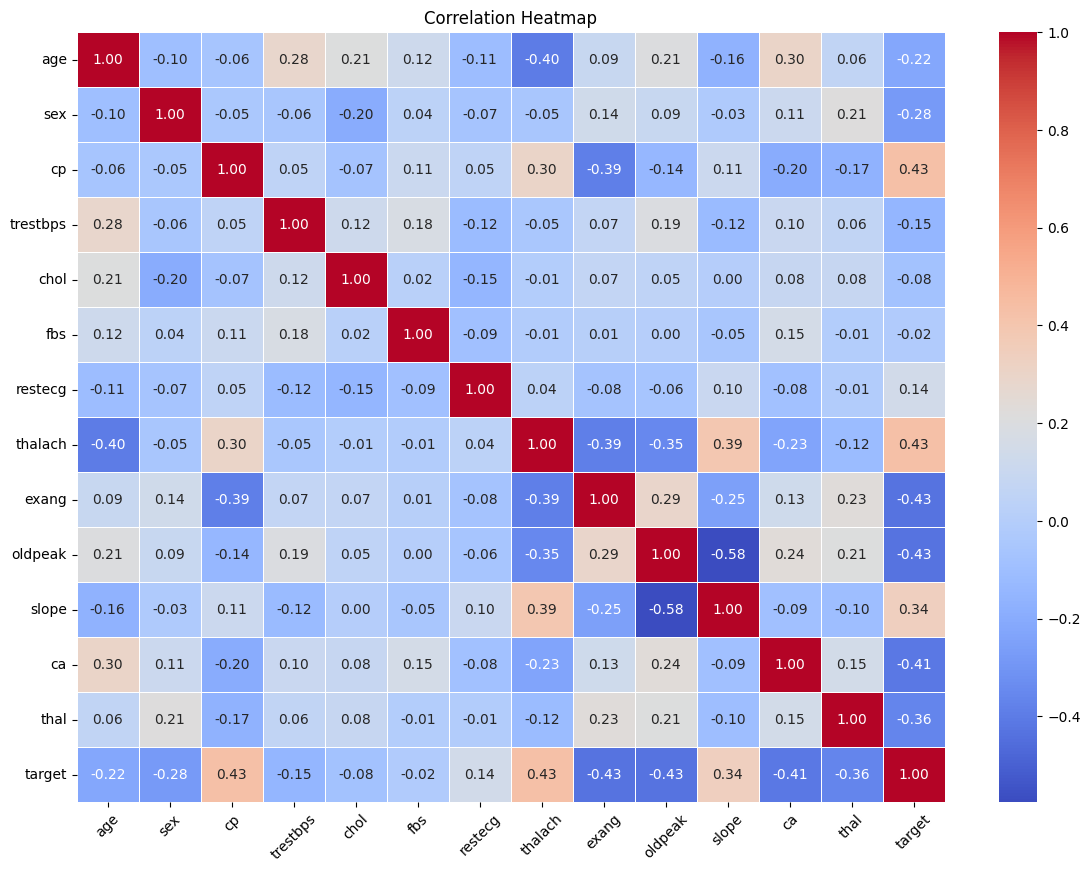

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.title("Correlation Heatmap")

plt.show()

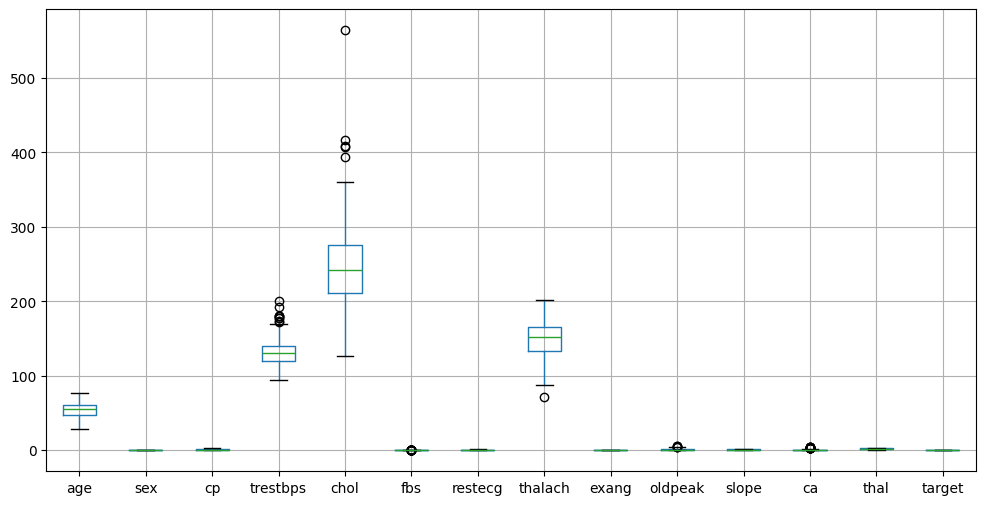

In [117]:
df.boxplot(figsize=(12,6))

plt.show()

In [118]:
cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled using IQR capping")

Outliers handled using IQR capping


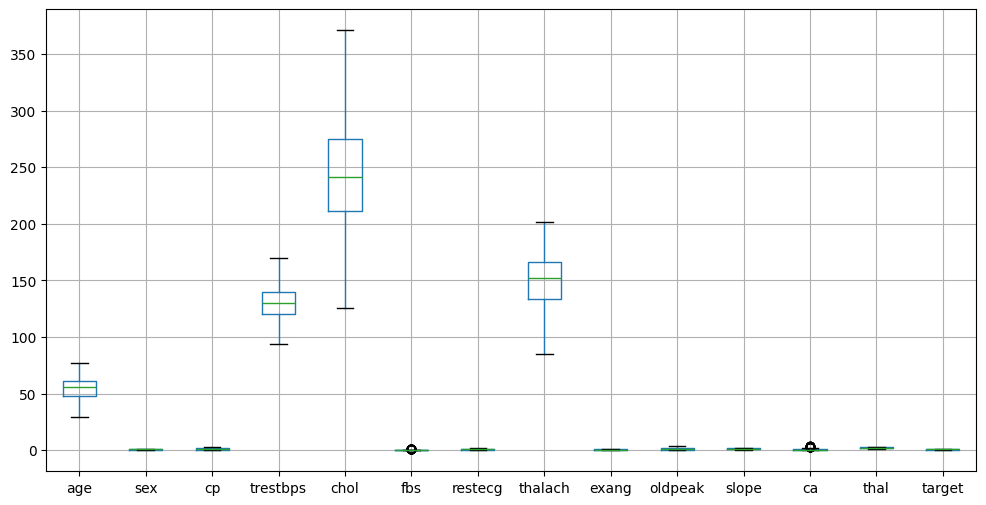

In [119]:
df.boxplot(figsize=(12,6))

plt.show()

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['age','trestbps', 'chol', 'thalach', 'oldpeak']#removed ca as it is a categorical and added age cuz it caused a issue in logistic classification since it was not normalised i beliieve

df[cols] = scaler.fit_transform(df[cols])

print(df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0 -0.268533    1   0 -0.377614 -0.707825    0        1  0.805634      0   
1 -0.158177    1   0  0.524330 -0.897290    1        0  0.232974      1   
2  1.717876    1   0  0.824978 -1.507787    0        1 -1.088551      1   
3  0.724671    1   0  1.005367 -0.897290    0        1  0.497279      0   
4  0.835027    0   0  0.404071  1.018407    1        1 -1.925516      0   

    oldpeak  slope  ca  thal  target  
0 -0.028212      2   2     3       0  
1  1.862567      0   0     3       0  
2  1.412381      0   0     3       0  
3 -0.928582      2   1     3       0  
4  0.782122      1   3     2       0  


In [121]:
# Features and target
X_reg = df.drop('chol', axis=1)
y_reg = df['chol']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)
print(X_train_reg.shape,X_test_reg.shape)

(240, 13) (60, 13)


In [122]:
X_clf = df.drop('target', axis=1)
y_clf = df['target']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)
print(X_train_reg.shape,X_test_reg.shape)

(240, 13) (60, 13)


In [123]:


# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train_reg, y_train_reg)

print("Linear Regression model trained")

Linear Regression model trained


In [125]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train_clf, y_train_clf)

print("Logistic Regression model trained") #normalizing age with standard fixed it

Logistic Regression model trained


In [126]:
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_clf, y_train_clf)

print("KNN model trained")

KNN model trained


In [127]:
from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train_clf, y_train_clf)

print("Naive Bayes model trained")

Naive Bayes model trained


In [128]:
y_pred_reg = lr.predict(X_test_reg)

In [129]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print("MAE:", mae)

MAE: 0.8091213548256279


In [130]:
mse = mean_squared_error(y_test_reg, y_pred_reg)

print("MSE:", mse)

MSE: 1.0236181616707403


In [131]:
r2 = r2_score(y_test_reg, y_pred_reg)

print("R2 Score:", r2)

R2 Score: -0.08203990298319863


In [132]:
y_pred_log = log_model.predict(X_test_clf)

In [133]:
y_pred_knn = knn_model.predict(X_test_clf)

In [134]:
y_pred_nb = nb_model.predict(X_test_clf)

In [135]:
accuracy = accuracy_score(y_test_clf, y_pred_log)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [136]:
precision = precision_score(y_test_clf, y_pred_log)

print("Precision:", precision)

Precision: 0.7272727272727273


In [137]:
recall = recall_score(y_test_clf, y_pred_log)

print("Recall:", recall)

Recall: 0.8888888888888888


In [138]:
f1 = f1_score(y_test_clf, y_pred_log)

print("F1 Score:", f1)

F1 Score: 0.8


In [141]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------- LOGISTIC REGRESSION ----------------

y_pred_log = log_model.predict(X_test_clf)

print("---- Logistic Regression ----")

print("Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print("Precision:", precision_score(y_test_clf, y_pred_log))
print("Recall:", recall_score(y_test_clf, y_pred_log))
print("F1-Score:", f1_score(y_test_clf, y_pred_log))


# ---------------- KNN ----------------

y_pred_knn = knn_model.predict(X_test_clf)

print("\n---- KNN ----")

print("Accuracy:", accuracy_score(y_test_clf, y_pred_knn))
print("Precision:", precision_score(y_test_clf, y_pred_knn))
print("Recall:", recall_score(y_test_clf, y_pred_knn))
print("F1-Score:", f1_score(y_test_clf, y_pred_knn))


# ---------------- NAIVE BAYES ----------------

y_pred_nb = nb_model.predict(X_test_clf)

print("\n---- Naive Bayes ----")

print("Accuracy:", accuracy_score(y_test_clf, y_pred_nb))
print("Precision:", precision_score(y_test_clf, y_pred_nb))
print("Recall:", recall_score(y_test_clf, y_pred_nb))
print("F1-Score:", f1_score(y_test_clf, y_pred_nb))


---- Logistic Regression ----
Accuracy: 0.8
Precision: 0.7272727272727273
Recall: 0.8888888888888888
F1-Score: 0.8

---- KNN ----
Accuracy: 0.75
Precision: 0.6666666666666666
Recall: 0.8888888888888888
F1-Score: 0.7619047619047619

---- Naive Bayes ----
Accuracy: 0.7833333333333333
Precision: 0.75
Recall: 0.7777777777777778
F1-Score: 0.7636363636363637
